In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Import your custom data loader module
from src.data_processing import load_data

# Load train, test, and store datasets
train_df, test_df, store_df = load_data()
train_df.head()

Matplotlib is building the font cache; this may take a moment.
2026-07-27 12:38:44,122 - INFO - Loading datasets...
2026-07-27 12:38:57,366 - INFO - Train shape: (1017209, 9), Test shape: (41088, 8), Store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


2026-07-27 12:43:29,256 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-27 12:43:32,974 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-27 12:43:35,086 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-27 12:43:35,338 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


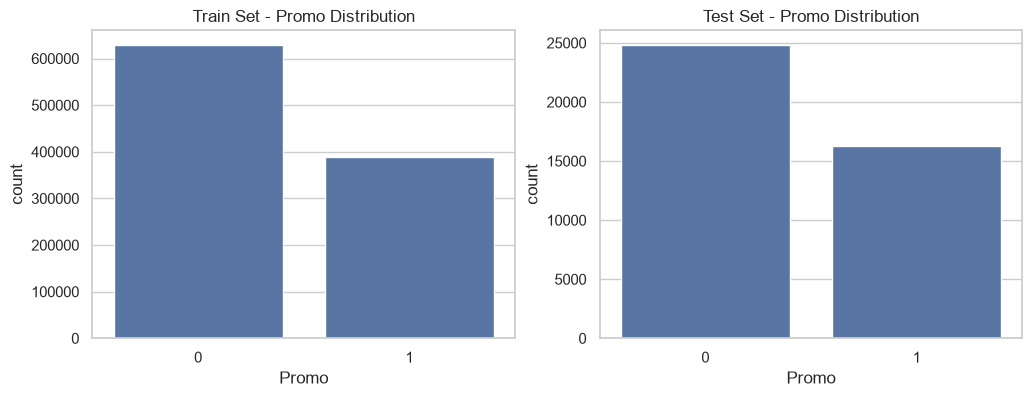

Correlation between Sales and Customers: 0.8947


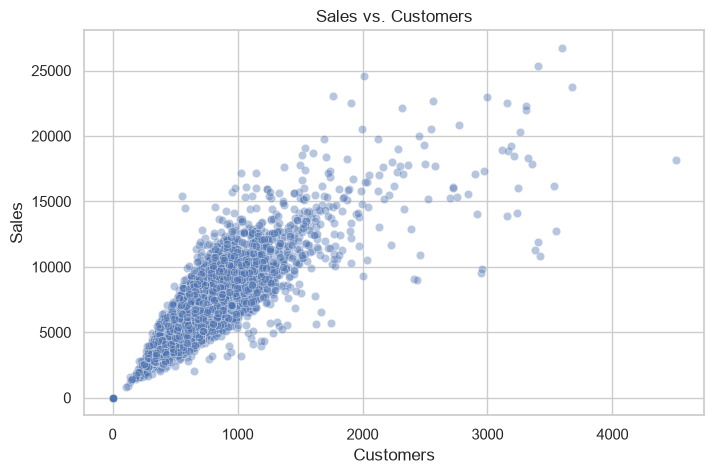

Sales summary when store is closed:
Sales
0    172817
Name: count, dtype: int64


In [2]:
# 1. Promo distribution in Train vs. Test sets
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train_df, x='Promo', ax=axes[0]).set(title='Train Set - Promo Distribution')
sns.countplot(data=test_df, x='Promo', ax=axes[1]).set(title='Test Set - Promo Distribution')
plt.show()

# 2. Sales vs. Customers Correlation
correlation = train_df[['Sales', 'Customers']].corr().iloc[0, 1]
print(f"Correlation between Sales and Customers: {correlation:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=train_df.sample(5000, random_state=42), x='Customers', y='Sales', alpha=0.4)
plt.title('Sales vs. Customers')
plt.show()

# 3. Sales Behavior: Store Open vs. Closed
print("Sales summary when store is closed:")
print(train_df[train_df['Open'] == 0]['Sales'].value_counts())